<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 100%); padding: 40px; border-radius: 10px; margin-bottom: 20px;">
<h1 style="color: white; margin: 0; font-size: 2.5em;">Lecture 6: Memory & Storage</h1>
<p style="color: #888; font-size: 1.2em; margin-top: 10px;">Part II: Devices & Circuits - SCE Futures</p>
</div>

## Contents

- [Learning Objectives](#learning-objectives)

1. [The Memory Challenge in SCE](#1-memory-challenge)
2. [Embedded State: The Hidden Storage](#2-embedded-state)
3. [Persistent Flux Storage](#3-loop-storage)
4. [The Addressing & Readout Problem](#4-addressing-problem)
5. [Register Files & FIFOs](#5-register-fifos)
6. [External Memory Integration](#6-external-memory)
7. [Memory for AI Workloads](#7-memory-ai)

- [Summary](#summary)

---
<a id="learning-objectives"></a>
## Learning Objectives

By the end of this session, you will be able to:

- Explain why traditional SRAM architecture doesn't translate to superconducting electronics
- Recognize that both AQFP and SFQ cells are clocked flip-flops with embedded state
- Understand persistent flux storage in superconducting loops and its advantages
- Identify the real challenge: addressing and readout, not storage itself
- Design register files and FIFOs using SCE primitives
- Understand interface requirements for external memory (HBM)
- Match memory architecture to workload requirements

**Terminology note**: "Flux trapping" in the SCE community typically refers to *unintended* defects—Abrikosov vortices or pearl vortices that become pinned during cooldown, causing soft failures. For *intentional* data storage, we use "persistent flux storage" or "flux-based storage" to avoid confusion.

In [1]:
# Setup
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
import numpy as np

COLORS = {
    'primary': '#2196F3',
    'secondary': '#FF9800',
    'success': '#4CAF50',
    'danger': '#f44336',
    'dark': '#1a1a2e',
    'light': '#f5f5f5',
    'purple': '#9C27B0',
    'cyan': '#00BCD4',
    'sram': '#E91E63',
    'fifo': '#4CAF50',
    'register': '#FF9800',
}

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['font.size'] = 11

print("Setup complete.")

Setup complete.


---
<a id="1-memory-challenge"></a>
# 1. The Memory Challenge in SCE
---

## Why CMOS SRAM Doesn't Translate

In CMOS, a 6-transistor (6T) SRAM cell stores a bit using cross-coupled inverters:

- Two stable states (0 or 1) maintained by transistor feedback
- Static power near zero (only leakage)
- Random access: any cell addressable in O(1) time

**The problem for SCE:**

| CMOS SRAM Property | SCE Reality |
|-------------------|-------------|
| Transistor bistability | No transistors - different physics |
| Random access | Addressing is the hard problem |
| Dense 6T cells | JJ cells larger (inductors, JJs) |
| Room-temp compatible | 4K operation requires cryo interface |

## The Real Picture: SCE Cells ARE Flip-Flops

Here's what's often overlooked: **both AQFP and SFQ logic cells are clocked flip-flops**. Every gate in an SCE pipeline naturally stores one bit of state.

| Logic Family | Basic Cell | Storage Mechanism |
|-------------|-----------|-------------------|
| AQFP | Buffer/gate | Clocked excitation stores state in inductors |
| RSFQ | DFF | SFQ pulse presence/absence in storage loop |
| ERSFQ | DFF | Same as RSFQ with bias optimization |

**Key insight**: Storage isn't the challenge - SCE gates store data naturally. The challenges are:
1. **Random access**: Addressing a specific bit among many
2. **Readout**: Extracting stored data without destroying it or using excessive energy
3. **Density**: Building large arrays efficiently

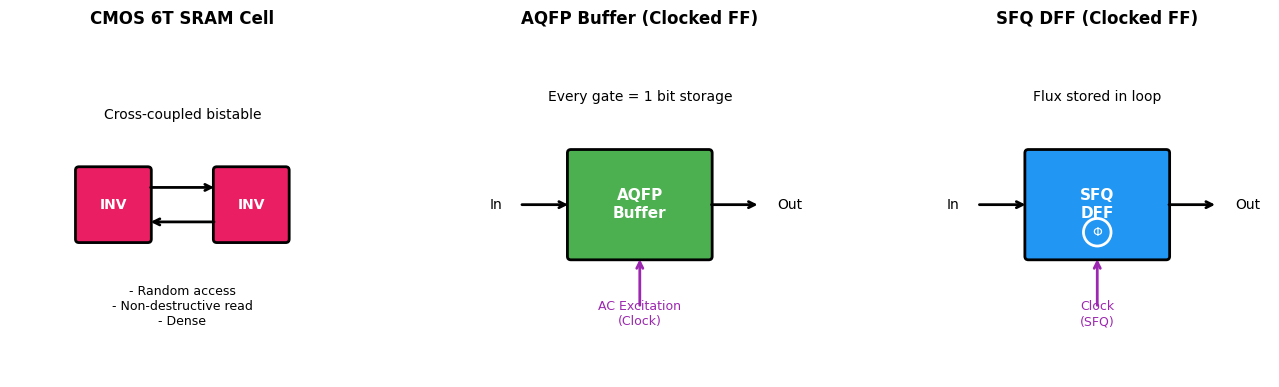


Key insight: Both AQFP and SFQ cells are clocked flip-flops.
Storage is inherent - the challenge is addressing and readout.


In [2]:
# Visualize: CMOS SRAM vs SCE storage concepts
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# CMOS 6T SRAM
ax = axes[0]
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('CMOS 6T SRAM Cell', fontsize=12, fontweight='bold')

# Draw cross-coupled inverters
inv1 = FancyBboxPatch((2, 4), 2, 2, boxstyle="round,pad=0.1", 
                       facecolor=COLORS['sram'], edgecolor='black', linewidth=2)
inv2 = FancyBboxPatch((6, 4), 2, 2, boxstyle="round,pad=0.1",
                       facecolor=COLORS['sram'], edgecolor='black', linewidth=2)
ax.add_patch(inv1)
ax.add_patch(inv2)
ax.text(3, 5, 'INV', ha='center', va='center', fontsize=10, color='white', fontweight='bold')
ax.text(7, 5, 'INV', ha='center', va='center', fontsize=10, color='white', fontweight='bold')

# Cross-coupling arrows
ax.annotate('', xy=(6, 5.5), xytext=(4, 5.5),
            arrowprops=dict(arrowstyle='->', color='black', lw=2))
ax.annotate('', xy=(4, 4.5), xytext=(6, 4.5),
            arrowprops=dict(arrowstyle='->', color='black', lw=2))

ax.text(5, 7.5, 'Cross-coupled bistable', ha='center', fontsize=10)
ax.text(5, 1.5, '- Random access\n- Non-destructive read\n- Dense', ha='center', fontsize=9)

# AQFP Buffer/Gate (Clocked Flip-Flop)
ax = axes[1]
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('AQFP Buffer (Clocked FF)', fontsize=12, fontweight='bold')

# Draw AQFP buffer as flip-flop
rect = FancyBboxPatch((3, 3.5), 4, 3, boxstyle="round,pad=0.1",
                       facecolor=COLORS['success'], edgecolor='black', linewidth=2)
ax.add_patch(rect)
ax.text(5, 5, 'AQFP\nBuffer', ha='center', va='center', fontsize=11, color='white', fontweight='bold')

# Clock input (bottom)
ax.annotate('', xy=(5, 3.5), xytext=(5, 2),
            arrowprops=dict(arrowstyle='->', color=COLORS['purple'], lw=2))
ax.text(5, 1.5, 'AC Excitation\n(Clock)', ha='center', fontsize=9, color=COLORS['purple'])

# Data in/out
ax.annotate('', xy=(3, 5), xytext=(1.5, 5),
            arrowprops=dict(arrowstyle='->', color='black', lw=2))
ax.annotate('', xy=(8.5, 5), xytext=(7, 5),
            arrowprops=dict(arrowstyle='->', color='black', lw=2))
ax.text(1, 5, 'In', ha='right', va='center', fontsize=10)
ax.text(9, 5, 'Out', ha='left', va='center', fontsize=10)

ax.text(5, 8, 'Every gate = 1 bit storage', ha='center', fontsize=10)

# SFQ DFF (Clocked Flip-Flop)
ax = axes[2]
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('SFQ DFF (Clocked FF)', fontsize=12, fontweight='bold')

# Draw SFQ DFF
rect = FancyBboxPatch((3, 3.5), 4, 3, boxstyle="round,pad=0.1",
                       facecolor=COLORS['primary'], edgecolor='black', linewidth=2)
ax.add_patch(rect)
ax.text(5, 5, 'SFQ\nDFF', ha='center', va='center', fontsize=11, color='white', fontweight='bold')

# Storage loop indicator
circle = plt.Circle((5, 4.2), 0.4, fill=False, color='white', linewidth=2)
ax.add_patch(circle)
ax.text(5, 4.2, 'Φ', ha='center', va='center', fontsize=9, color='white')

# Clock input
ax.annotate('', xy=(5, 3.5), xytext=(5, 2),
            arrowprops=dict(arrowstyle='->', color=COLORS['purple'], lw=2))
ax.text(5, 1.5, 'Clock\n(SFQ)', ha='center', fontsize=9, color=COLORS['purple'])

# Data in/out
ax.annotate('', xy=(3, 5), xytext=(1.5, 5),
            arrowprops=dict(arrowstyle='->', color='black', lw=2))
ax.annotate('', xy=(8.5, 5), xytext=(7, 5),
            arrowprops=dict(arrowstyle='->', color='black', lw=2))
ax.text(1, 5, 'In', ha='right', va='center', fontsize=10)
ax.text(9, 5, 'Out', ha='left', va='center', fontsize=10)

ax.text(5, 8, 'Flux stored in loop', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print("\nKey insight: Both AQFP and SFQ cells are clocked flip-flops.")
print("Storage is inherent - the challenge is addressing and readout.")

---
<a id="2-embedded-state"></a>
# 2. Embedded State: The Hidden Storage
---

Since every SCE gate is a clocked flip-flop, **pipelines inherently contain storage**. This "embedded state" is often overlooked but is crucial for understanding SCE memory architecture.

## AQFP: Every Buffer Stores a Bit

In AQFP, the fundamental operation involves:
1. AC excitation raises the potential energy landscape
2. Input current biases toward 0 or 1 state
3. Excitation captures the state in the inductor
4. State persists until next clock phase

This means an AQFP buffer **is** a D flip-flop - it samples input on one clock phase and holds it until the next.

**Important**: AQFP storage is **not static**. Data must keep moving through the pipeline - every clock phase, data shifts to the next stage. If you need to hold data longer:
- Keep it circulating through a shift register loop, or
- Stop the clock entirely (possible in principle, but not used in current architectures)

This continuous-motion requirement shapes AQFP memory architecture toward FIFOs and streaming patterns.

## SFQ: Persistent Flux in Loops

In SFQ logic, a D flip-flop stores a bit as the presence/absence of a flux quantum (Φ₀) in a superconducting loop:
- **Write**: SFQ pulse adds flux to the loop
- **Store**: Persistent supercurrent maintains the flux (no transients, no switching)
- **Read**: Clock pulse extracts/copies the stored state

**The stored flux is static** - unlike SFQ *signaling* which uses transient pulses, *storage* uses persistent currents with no switching activity. An SFQ DFF can hold its state indefinitely without clocking.

## AQFP vs SFQ Storage Comparison

| Property | AQFP | SFQ |
|----------|------|-----|
| Storage mechanism | Inductor state during excitation | Persistent flux in loop |
| Static? | No - requires continuous clocking | Yes - holds without clock |
| To hold data | Keep circulating or stop clock | Just don't clock out |
| Natural fit | Streaming/dataflow | Both streaming and static |

## SR Latches in AQFP

AQFP can also implement SR (Set-Reset) latches using feedback loops:

```
Set ───┬───[AQFP OR]───┬─── Q
       │               │
       └───[AQFP AND]──┘
                │
Reset ──────────┘
```

These provide explicit storage elements, but still require continuous clocking to maintain state.

## Quantifying Embedded State

For a dataflow architecture with N pipeline stages, each W bits wide:

```
Embedded storage = N × W bits
```

**Example**: A systolic array with 256×256 cells, 4-phase AQFP clocking:
- Pipeline stages per cell: ~4 (one per clock phase)
- Bits per cell: 16 (for FP16 accumulation)
- Total embedded state: 256 × 256 × 4 × 16 = **~4.2 million bits** (~512 KB)

This is "free" storage that comes with the datapath - no separate memory cells needed. But in AQFP, this data is always in motion.

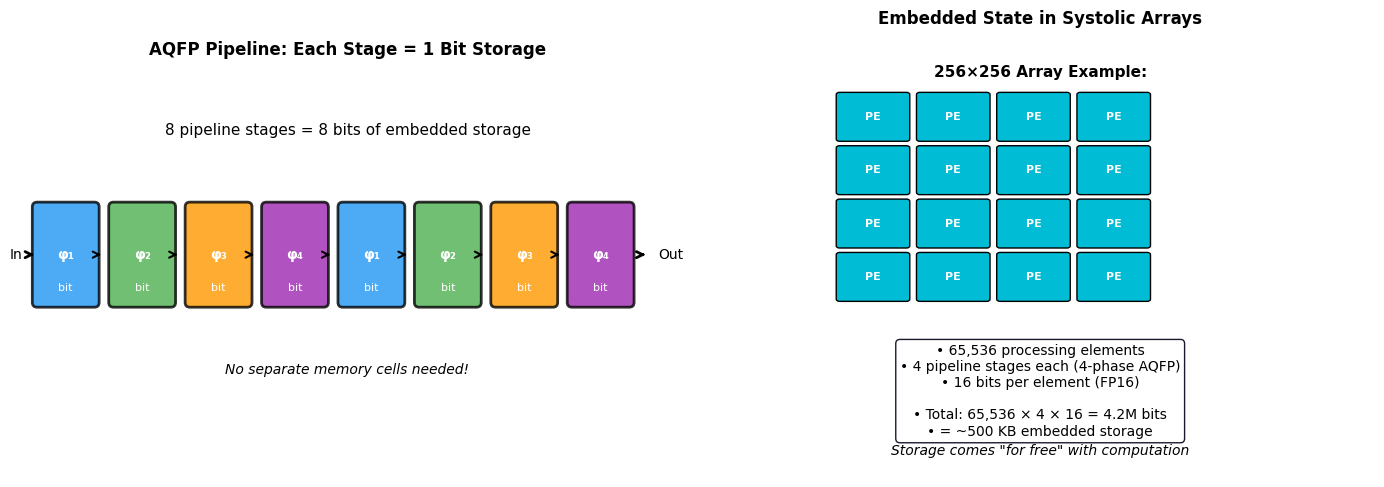


Embedded state is why SCE can work with minimal explicit memory.
The pipeline IS the storage.


In [3]:
# Visualize: Embedded state in SCE pipelines
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# AQFP Pipeline with embedded state
ax = axes[0]
ax.set_xlim(0, 14)
ax.set_ylim(0, 8)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('AQFP Pipeline: Each Stage = 1 Bit Storage', fontsize=12, fontweight='bold')

# Clock phases
phases = ['φ₁', 'φ₂', 'φ₃', 'φ₄']
phase_colors = [COLORS['primary'], COLORS['success'], COLORS['secondary'], COLORS['purple']]

# Draw pipeline stages
for i in range(8):
    phase_idx = i % 4
    color = phase_colors[phase_idx]
    
    rect = FancyBboxPatch((i*1.6 + 0.5, 3), 1.2, 2, boxstyle="round,pad=0.1",
                          facecolor=color, edgecolor='black', linewidth=2, alpha=0.8)
    ax.add_patch(rect)
    ax.text(i*1.6 + 1.1, 4, phases[phase_idx], ha='center', va='center', 
            fontsize=10, color='white', fontweight='bold')
    
    # Show stored bit
    ax.text(i*1.6 + 1.1, 3.3, f'bit', ha='center', va='center', 
            fontsize=8, color='white')
    
    # Connection arrows
    if i < 7:
        ax.annotate('', xy=(i*1.6 + 1.9, 4), xytext=(i*1.6 + 1.7, 4),
                    arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

# Labels
ax.text(0.2, 4, 'In', ha='right', va='center', fontsize=10)
ax.text(13.5, 4, 'Out', ha='left', va='center', fontsize=10)
ax.annotate('', xy=(0.5, 4), xytext=(0.3, 4),
            arrowprops=dict(arrowstyle='->', color='black', lw=2))
ax.annotate('', xy=(13.3, 4), xytext=(13.1, 4),
            arrowprops=dict(arrowstyle='->', color='black', lw=2))

ax.text(7, 6.5, '8 pipeline stages = 8 bits of embedded storage', ha='center', fontsize=11)
ax.text(7, 1.5, 'No separate memory cells needed!', ha='center', fontsize=10, style='italic')

# Embedded state calculation
ax = axes[1]
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')
ax.set_title('Embedded State in Systolic Arrays', fontsize=12, fontweight='bold')

# Draw small systolic array representation
for i in range(4):
    for j in range(4):
        rect = FancyBboxPatch((i*1.2 + 2, j*1.2 + 4), 1, 1, boxstyle="round,pad=0.05",
                              facecolor=COLORS['cyan'], edgecolor='black', linewidth=1)
        ax.add_patch(rect)
        ax.text(i*1.2 + 2.5, j*1.2 + 4.5, 'PE', ha='center', va='center', 
                fontsize=8, color='white', fontweight='bold')

# Calculations
ax.text(5, 9, '256×256 Array Example:', ha='center', fontsize=11, fontweight='bold')
ax.text(5, 3, '• 65,536 processing elements\n• 4 pipeline stages each (4-phase AQFP)\n• 16 bits per element (FP16)\n\n• Total: 65,536 × 4 × 16 = 4.2M bits\n• = ~500 KB embedded storage', 
        ha='center', va='top', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='white', edgecolor=COLORS['dark']))

ax.text(5, 0.5, 'Storage comes "for free" with computation', ha='center', fontsize=10, style='italic')

plt.tight_layout()
plt.show()

print("\nEmbedded state is why SCE can work with minimal explicit memory.")
print("The pipeline IS the storage.")

---
<a id="3-loop-storage"></a>
# 3. Persistent Flux Storage
---

Beyond embedded pipeline state, SCE can store data **statically** in superconducting loops using persistent circulating currents.

## The Physics of Flux Storage

A closed superconducting loop has a remarkable property: **flux quantization**. The magnetic flux through the loop must be an integer multiple of Φ₀ = h/2e ≈ 2.07 × 10⁻¹⁵ Wb.

**Key insight**: Once a flux quantum is stored in a superconducting loop, it persists indefinitely (as long as the loop remains superconducting). A persistent supercurrent circulates to maintain the flux—this is **true static storage**:
- No switching activity required to maintain state
- No refresh cycles (unlike DRAM)
- No leakage (unlike CMOS SRAM)
- Persistent current circulates with zero resistance

**Terminology**: We call this "persistent flux storage" or "flux-based storage." The term "flux trapping" is reserved for *unintended* defects—Abrikosov vortices that become pinned at random locations during cooldown, causing soft failures. Don't confuse intentional storage with defect-induced errors.

## Storage vs Signaling

It's important to distinguish:

| Aspect | SFQ Signaling | Persistent Flux Storage |
|--------|--------------|-------------------------|
| Mechanism | Transient voltage pulses | Persistent circulating current |
| Duration | Picoseconds | Indefinite |
| Energy | ~1 aJ per pulse | Zero (static) |
| Purpose | Data transmission | Data retention |

**The confusion**: SFQ *signaling* involves transient switching. But SFQ *storage* is static—persistent currents maintain flux quanta with no transients.

## Storage Cell Structure

A basic storage cell uses a superconducting loop interrupted by Josephson junctions:

```
       ┌───[JJ]───┐
       │          │
Write ─┤    L     ├─ Read
       │  (Φ₀)    │
       └───[JJ]───┘
```

- **L**: Inductance that stores the flux quantum
- **JJ**: Josephson junctions that control write/read operations
- **Φ₀**: Stored flux quantum (presence = 1, absence = 0)

## Why This Matters

Persistent flux storage means SCE memory cells:
1. Don't consume power to retain data
2. Don't require periodic refresh
3. Can theoretically achieve very high density

**But** (and this is crucial): the challenge isn't storage—it's **getting data in and out efficiently**.

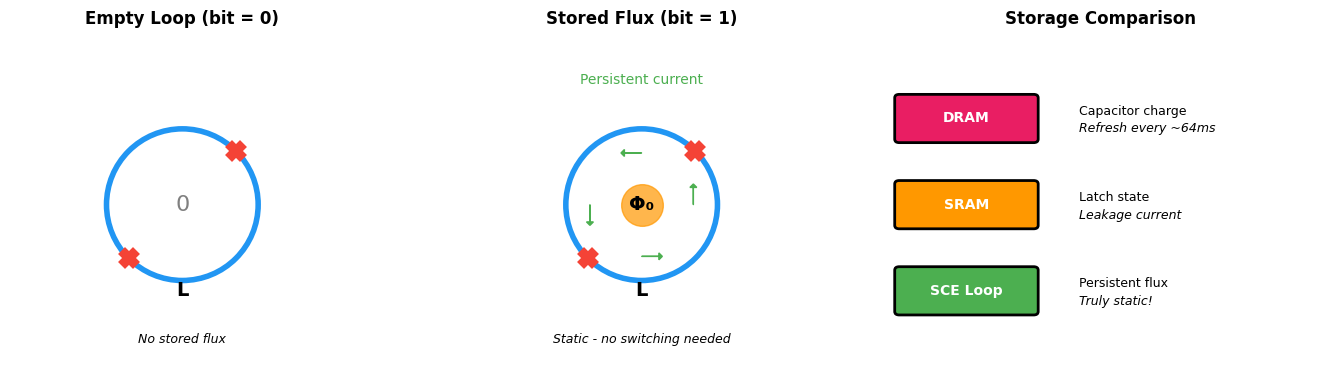


Persistent flux storage is truly static - the challenge is addressing and readout, not retention.


In [4]:
# Visualize: Persistent flux storage in superconducting loops
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

def draw_storage_loop(ax, state, title, subtitle):
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title, fontsize=12, fontweight='bold')
    
    # Storage loop
    loop = plt.Circle((5, 5), 2.2, fill=False, color=COLORS['primary'], linewidth=4)
    ax.add_patch(loop)
    
    # Josephson junctions (shown as X marks on the loop)
    for angle, label in [(45, 'JJ'), (225, 'JJ')]:
        rad = np.radians(angle)
        x = 5 + 2.2 * np.cos(rad)
        y = 5 + 2.2 * np.sin(rad)
        ax.plot(x, y, 'X', markersize=12, color=COLORS['danger'], markeredgewidth=3)
    
    # Inductor representation (coil symbol at bottom)
    ax.text(5, 2.5, 'L', ha='center', va='center', fontsize=14, fontweight='bold')
    
    if state == 'stored':
        # Flux quantum indicator
        ax.plot(5, 5, 'o', markersize=30, color=COLORS['secondary'], alpha=0.7)
        ax.text(5, 5, 'Φ₀', ha='center', va='center', fontsize=14, fontweight='bold')
        
        # Circulating current arrows (show persistent current)
        for angle in [0, 90, 180, 270]:
            rad = np.radians(angle)
            x1 = 5 + 1.5 * np.cos(rad)
            y1 = 5 + 1.5 * np.sin(rad)
            dx = -0.5 * np.sin(rad)
            dy = 0.5 * np.cos(rad)
            ax.arrow(x1, y1, dx, dy, head_width=0.2, head_length=0.1, 
                    fc=COLORS['success'], ec=COLORS['success'])
        
        ax.text(5, 8.5, 'Persistent current', ha='center', fontsize=10, color=COLORS['success'])
    else:
        ax.text(5, 5, '0', ha='center', va='center', fontsize=16, color='gray')
    
    ax.text(5, 1, subtitle, ha='center', fontsize=9, style='italic')

draw_storage_loop(axes[0], 'empty', 'Empty Loop (bit = 0)', 'No stored flux')
draw_storage_loop(axes[1], 'stored', 'Stored Flux (bit = 1)', 'Static - no switching needed')

# Comparison with DRAM/SRAM
ax = axes[2]
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')
ax.set_title('Storage Comparison', fontsize=12, fontweight='bold')

data = [
    ('DRAM', 'Capacitor charge', 'Refresh every ~64ms', COLORS['sram']),
    ('SRAM', 'Latch state', 'Leakage current', COLORS['register']),
    ('SCE Loop', 'Persistent flux', 'Truly static!', COLORS['success']),
]

for i, (name, mechanism, note, color) in enumerate(data):
    y = 7.5 - i * 2.5
    rect = FancyBboxPatch((0.5, y - 0.6), 3, 1.2, boxstyle="round,pad=0.1",
                          facecolor=color, edgecolor='black', linewidth=2)
    ax.add_patch(rect)
    ax.text(2, y, name, ha='center', va='center', fontsize=10, color='white', fontweight='bold')
    ax.text(4.5, y + 0.2, mechanism, ha='left', va='center', fontsize=9)
    ax.text(4.5, y - 0.3, note, ha='left', va='center', fontsize=9, style='italic')

plt.tight_layout()
plt.show()

print("\nPersistent flux storage is truly static - the challenge is addressing and readout, not retention.")

---
<a id="4-addressing-problem"></a>
# 4. The Addressing & Readout Problem
---

If superconducting loops can store flux statically and efficiently, why don't we have large SCE memory arrays? The answer: **addressing and readout are hard**.

## The Core Challenge

In CMOS SRAM, transistors act as switches:
- Address lines activate word lines
- Word lines enable access transistors
- Bit lines sense or write data

SCE has no transistors. Josephson junctions are **two-terminal devices** - they can't "gate" signals the way transistors do.

## Historical Approach: Flux Pumps

Early SCE memory attempts used **flux pumps** - circuits that amplify weak readout signals:

```
Storage Cell → [JJ Comparator] → [Flux Pump] → Output
                                      ↓
                                 High energy!
```

**The problem**: Flux pumps consume significant energy (~100× the storage cell switching energy), defeating the efficiency advantage of SCE.

## Why Readout is Expensive

To read a stored flux quantum, you need to:
1. **Sense** the tiny magnetic field or current (~μA scale)
2. **Amplify** it to a usable signal level
3. **Select** which cell to read (addressing)

Each step requires energy. In traditional SFQ memory arrays:
- Row decoders require many JJ switches
- Column multiplexers add more
- Sense amplifiers need bias current

## NDRO (Non-Destructive Read-Out) Cells

One improvement: NDRO cells use SQUIDs to sense stored flux without destroying it:

```
      ┌────────────┐
      │   SQUID    │──→ Readout
      │  Sensor    │
      └─────┬──────┘
            │
      ┌─────┴──────┐
      │  Storage   │
      │    Loop    │
      └────────────┘
```

**Trade-offs**:
- Non-destructive reads (good!)
- Larger cell area (~2× basic cell)
- Still needs addressing infrastructure

## The Density-Efficiency Trade-off

| Approach | Density | Read Energy | Random Access |
|----------|---------|-------------|---------------|
| Pipeline registers | Low | ~1 aJ | No (sequential) |
| Shift registers | Medium | ~1 aJ/stage | No (sequential) |
| NDRO arrays | High | ~100 aJ | Yes, but expensive |
| Flux pump arrays | High | ~1000 aJ | Yes, but defeats purpose |

**Key insight**: For large random-access storage, external CMOS memory (HBM) is more practical than native SCE arrays.

---
<a id="5-register-fifos"></a>
# 5. Register Files & FIFOs
---

Given the addressing challenges, practical SCE systems use storage patterns that avoid random access:

1. **Register files**: Small, fixed-location storage
2. **FIFOs/Shift registers**: Sequential access only
3. **Embedded pipeline state**: "Free" storage in the datapath

## FIFO Architecture

FIFOs are natural for SCE because they match the sequential nature of flip-flop chains:

```
Write Port → [DFF] → [DFF] → ... → [DFF] → Read Port
               ↑       ↑             ↑
              CLK     CLK           CLK
```

In AQFP, this is simply a chain of buffers. In SFQ, it's a chain of DFFs. Either way:
- **No addressing logic needed** - data flows in one direction
- **Constant energy per stage** - no expensive readout
- **Natural fit for streaming workloads**

**Key parameters:**
- **Depth**: Number of entries (stages)
- **Width**: Bits per entry
- **Throughput**: One entry per clock cycle

## Register File with Limited Access

For cases requiring some random access, a **banked register file** provides a middle ground:

```
          ┌─────────┐
Write → │ Bank 0  │ ← Read (selected bank)
          ├─────────┤
          │ Bank 1  │
          ├─────────┤
          │ Bank 2  │
          ├─────────┤
          │ Bank 3  │
          └─────────┘
              ↑
         Bank Select (small decoder)
```

- Access any bank in O(1) with small decoder overhead
- Within each bank, use sequential access (shift register)
- Trade-off: More banks = more random access, but higher area

## Accumulators: The Sweet Spot

For AI workloads, **edge accumulators** are the most important storage:

- Located at systolic array outputs
- Accumulate partial sums across multiple cycles
- Read out sequentially when complete
- Size: batch × tile_width × bytes_per_element

This matches embedded state well - the accumulator IS part of the pipeline.

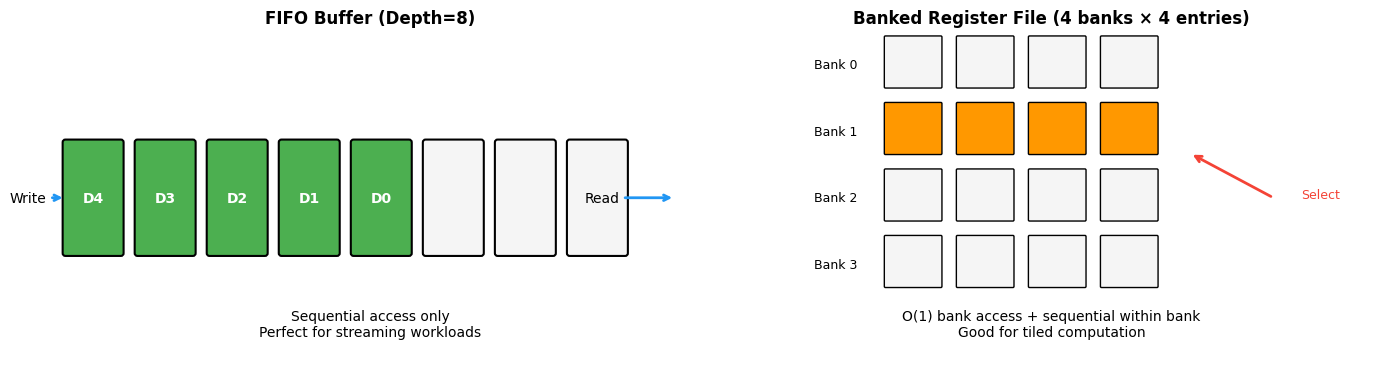

In [5]:
# Visualize: FIFO vs Banked Register File
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# FIFO
ax = axes[0]
ax.set_xlim(0, 12)
ax.set_ylim(0, 6)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('FIFO Buffer (Depth=8)', fontsize=12, fontweight='bold')

for i in range(8):
    color = COLORS['fifo'] if i < 5 else COLORS['light']
    rect = FancyBboxPatch((i*1.3 + 0.5, 2), 1, 2, boxstyle="round,pad=0.05",
                          facecolor=color, edgecolor='black', linewidth=1.5)
    ax.add_patch(rect)
    if i < 5:
        ax.text(i*1.3 + 1, 3, f'D{4-i}', ha='center', va='center', 
                fontsize=10, color='white', fontweight='bold')

ax.annotate('Write', xy=(0.5, 3), xytext=(-0.5, 3),
            arrowprops=dict(arrowstyle='->', color=COLORS['primary'], lw=2),
            fontsize=10, va='center')
ax.annotate('Read', xy=(11.5, 3), xytext=(10.5, 3),
            arrowprops=dict(arrowstyle='->', color=COLORS['primary'], lw=2),
            fontsize=10, va='center', ha='right')

ax.text(6, 0.5, 'Sequential access only\nPerfect for streaming workloads', 
        ha='center', fontsize=10)

# Banked Register File
ax = axes[1]
ax.set_xlim(0, 12)
ax.set_ylim(0, 6)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Banked Register File (4 banks × 4 entries)', fontsize=12, fontweight='bold')

for bank in range(4):
    for entry in range(4):
        color = COLORS['register'] if bank == 1 else COLORS['light']
        rect = FancyBboxPatch((entry*1.3 + 3, 5 - bank*1.2), 1, 0.9,
                              boxstyle="round,pad=0.02", facecolor=color,
                              edgecolor='black', linewidth=1)
        ax.add_patch(rect)
    ax.text(2.5, 5.4 - bank*1.2, f'Bank {bank}', ha='right', va='center', fontsize=9)

# Bank select arrow
ax.annotate('', xy=(8.5, 3.8), xytext=(10, 3),
            arrowprops=dict(arrowstyle='->', color=COLORS['danger'], lw=2))
ax.text(10.5, 3, 'Select', fontsize=9, color=COLORS['danger'])

ax.text(6, 0.5, 'O(1) bank access + sequential within bank\nGood for tiled computation', 
        ha='center', fontsize=10)

plt.tight_layout()
plt.show()

---
<a id="6-external-memory"></a>
# 6. External Memory Integration
---

For AI workloads requiring gigabytes of storage (model weights, KV cache), on-chip SCE memory is insufficient. The solution: **external memory at higher temperature stages**.

## Memory Hierarchy

```
┌─────────────────────────────────────────┐
│            4K Stage (SCE)               │
│  ┌─────────────────────────────────┐    │
│  │  Compute Array (Systolic/AQFP)  │    │
│  │      + Local Registers          │    │
│  │      + FIFOs / Accumulators     │    │
│  └─────────────────────────────────┘    │
│              ↕ High-BW Link             │
└─────────────────────────────────────────┘
              ↕ Cryo Interface
┌─────────────────────────────────────────┐
│         77K or 300K Stage               │
│  ┌─────────────────────────────────┐    │
│  │        HBM / DDR Memory         │    │
│  │         (GB scale)              │    │
│  └─────────────────────────────────┘    │
└─────────────────────────────────────────┘
```

## Interface Challenges

| Challenge | Solution |
|-----------|----------|
| Thermal load from I/O | Minimize wire count, use SerDes |
| Signal integrity | Impedance matching across temp stages |
| Bandwidth | Wide parallel buses or high-speed serial |
| Latency | Prefetching, double buffering |

## HBM Bandwidth

Modern HBM (High Bandwidth Memory) provides:
- **HBM2e**: ~460 GB/s per stack
- **HBM3**: ~800 GB/s per stack
- **HBM3e**: ~1.2 TB/s per stack

With multiple stacks, total bandwidth can reach several TB/s - matching or exceeding GPU memory bandwidth.

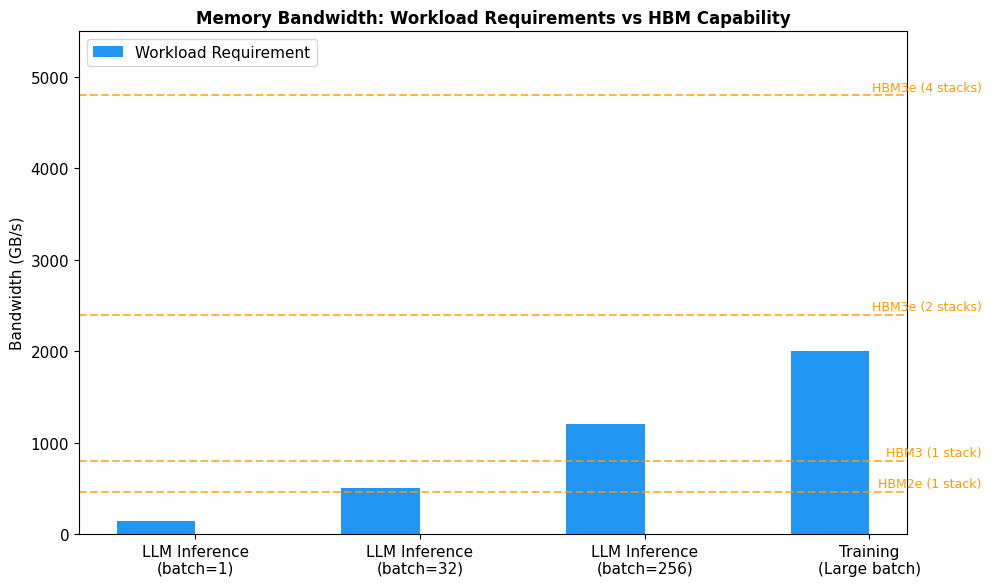

Key insight: HBM provides sufficient bandwidth for most inference workloads.
The challenge is the cryo interface, not raw memory bandwidth.


In [6]:
# Visualize: Memory bandwidth requirements vs HBM capability
fig, ax = plt.subplots(figsize=(10, 6))

# Workload bandwidth requirements (GB/s)
workloads = {
    'LLM Inference\n(batch=1)': 140,
    'LLM Inference\n(batch=32)': 500,
    'LLM Inference\n(batch=256)': 1200,
    'Training\n(Large batch)': 2000,
}

# Memory capabilities
memory_bw = {
    'HBM2e (1 stack)': 460,
    'HBM3 (1 stack)': 800,
    'HBM3e (2 stacks)': 2400,
    'HBM3e (4 stacks)': 4800,
}

x = np.arange(len(workloads))
width = 0.35

bars1 = ax.bar(x - width/2, list(workloads.values()), width, 
               label='Workload Requirement', color=COLORS['primary'])

# Add HBM capability lines
for name, bw in memory_bw.items():
    ax.axhline(y=bw, color=COLORS['secondary'], linestyle='--', alpha=0.7)
    ax.text(len(workloads)-0.5, bw + 50, name, fontsize=9, 
            color=COLORS['secondary'], ha='right')

ax.set_ylabel('Bandwidth (GB/s)', fontsize=11)
ax.set_title('Memory Bandwidth: Workload Requirements vs HBM Capability', 
             fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(list(workloads.keys()))
ax.legend(loc='upper left')
ax.set_ylim(0, 5500)

plt.tight_layout()
plt.show()

print("Key insight: HBM provides sufficient bandwidth for most inference workloads.")
print("The challenge is the cryo interface, not raw memory bandwidth.")

---
<a id="7-memory-ai"></a>
# 7. Memory for AI Workloads
---

SCE AI accelerators use a memory architecture optimized for deterministic dataflow - the same patterns that GPUs exploit, just implemented more efficiently.

## What GPUs Actually Do for Matrix Ops

Despite having complex cache hierarchies, GPUs perform matrix operations with predictable access patterns:

1. **Weights**: Streamed from HBM → L2 → Shared Memory → Registers
2. **Activations**: Tiled and streamed through the compute units
3. **Accumulators**: Per-thread registers accumulate partial sums

The caches exist for *other* workloads. For matrix multiply, access is deterministic.

## SCE Exploits the Same Patterns

SCE doesn't need complex caches because it targets workloads where access is predictable:

| Component | GPU Approach | SCE Approach |
|-----------|-------------|---------------|
| Weight storage | HBM → L2 → Shared Mem | HBM → Input FIFO |
| Activation buffer | Shared memory tiles | FIFOs between stages |
| Partial sums | Register file | Edge accumulators (embedded state) |
| KV cache | HBM (sequential access) | HBM (same pattern) |

**The key**: Both architectures exploit predictable access. SCE just does it with simpler, more efficient hardware.

## Why This Works for LLM Inference

LLM inference has **highly predictable** memory access patterns:

1. **Weights**: Streamed once per token, same order every time
2. **KV cache**: Append-only (new tokens) + sequential read (attention)
3. **Activations**: Flow through layers in fixed order

These patterns → **FIFOs + embedded accumulators are sufficient**.

### Embedded State Sizing

For a systolic array processing matrix tiles:

```
Embedded state ≈ Array_M × Array_N × Pipeline_Depth × Bits_per_Element
```

For a 256×256 array with 4-stage pipeline and FP16:
```
Embedded state = 256 × 256 × 4 × 16 bits ≈ 500 KB
```

This "free" storage handles all the partial sums and pipeline buffering that would require explicit SRAM in other architectures.

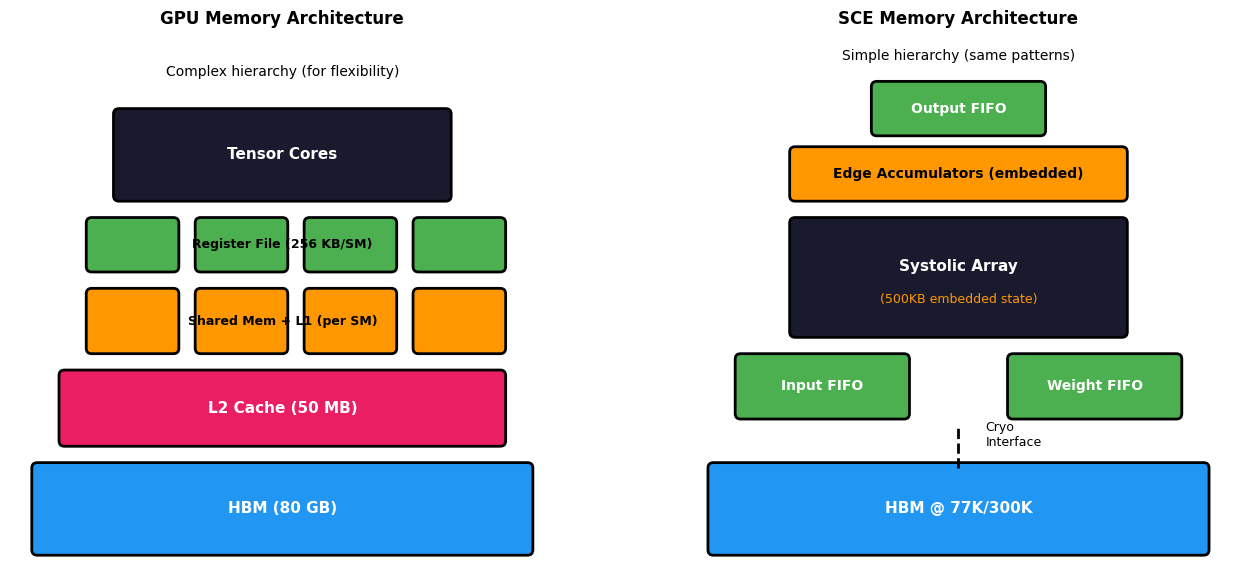


Both architectures exploit the same predictable access patterns in matrix operations.
SCE achieves this with simpler hardware because it doesn't need to support random access.


In [7]:
# Visualize: GPU vs SCE memory architecture comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# GPU Architecture
ax = axes[0]
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('GPU Memory Architecture', fontsize=12, fontweight='bold')

# HBM
rect = FancyBboxPatch((0.5, 0.5), 9, 1.5, boxstyle="round,pad=0.1",
                       facecolor=COLORS['primary'], edgecolor='black', linewidth=2)
ax.add_patch(rect)
ax.text(5, 1.25, 'HBM (80 GB)', ha='center', va='center', fontsize=11, color='white', fontweight='bold')

# L2 Cache
rect = FancyBboxPatch((1, 2.5), 8, 1.2, boxstyle="round,pad=0.1",
                       facecolor=COLORS['sram'], edgecolor='black', linewidth=2)
ax.add_patch(rect)
ax.text(5, 3.1, 'L2 Cache (50 MB)', ha='center', va='center', fontsize=11, color='white', fontweight='bold')

# Shared Memory / L1
for i in range(4):
    rect = FancyBboxPatch((1.5 + i*2, 4.2), 1.5, 1, boxstyle="round,pad=0.1",
                          facecolor=COLORS['register'], edgecolor='black', linewidth=2)
    ax.add_patch(rect)
ax.text(5, 4.7, 'Shared Mem + L1 (per SM)', ha='center', va='center', fontsize=9, fontweight='bold')

# Register File
for i in range(4):
    rect = FancyBboxPatch((1.5 + i*2, 5.7), 1.5, 0.8, boxstyle="round,pad=0.1",
                          facecolor=COLORS['success'], edgecolor='black', linewidth=2)
    ax.add_patch(rect)
ax.text(5, 6.1, 'Register File (256 KB/SM)', ha='center', va='center', fontsize=9, fontweight='bold')

# Compute
rect = FancyBboxPatch((2, 7), 6, 1.5, boxstyle="round,pad=0.1",
                       facecolor=COLORS['dark'], edgecolor='black', linewidth=2)
ax.add_patch(rect)
ax.text(5, 7.75, 'Tensor Cores', ha='center', va='center', fontsize=11, color='white', fontweight='bold')

ax.text(5, 9.2, 'Complex hierarchy (for flexibility)', ha='center', fontsize=10)

# SCE Architecture
ax = axes[1]
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('SCE Memory Architecture', fontsize=12, fontweight='bold')

# HBM (external)
rect = FancyBboxPatch((0.5, 0.5), 9, 1.5, boxstyle="round,pad=0.1",
                       facecolor=COLORS['primary'], edgecolor='black', linewidth=2)
ax.add_patch(rect)
ax.text(5, 1.25, 'HBM @ 77K/300K', ha='center', va='center', fontsize=11, color='white', fontweight='bold')

# Cryo interface
ax.plot([5, 5], [2, 2.8], 'k--', linewidth=2)
ax.text(5.5, 2.4, 'Cryo\nInterface', ha='left', fontsize=9)

# Input FIFO
rect = FancyBboxPatch((1, 3), 3, 1, boxstyle="round,pad=0.1",
                       facecolor=COLORS['fifo'], edgecolor='black', linewidth=2)
ax.add_patch(rect)
ax.text(2.5, 3.5, 'Input FIFO', ha='center', va='center', fontsize=10, color='white', fontweight='bold')

# Weight FIFO
rect = FancyBboxPatch((6, 3), 3, 1, boxstyle="round,pad=0.1",
                       facecolor=COLORS['fifo'], edgecolor='black', linewidth=2)
ax.add_patch(rect)
ax.text(7.5, 3.5, 'Weight FIFO', ha='center', va='center', fontsize=10, color='white', fontweight='bold')

# Compute array with embedded state
rect = FancyBboxPatch((2, 4.5), 6, 2, boxstyle="round,pad=0.1",
                       facecolor=COLORS['dark'], edgecolor='black', linewidth=2)
ax.add_patch(rect)
ax.text(5, 5.7, 'Systolic Array', ha='center', va='center', fontsize=11, color='white', fontweight='bold')
ax.text(5, 5.1, '(500KB embedded state)', ha='center', va='center', fontsize=9, color=COLORS['secondary'])

# Edge accumulators (embedded)
rect = FancyBboxPatch((2, 7), 6, 0.8, boxstyle="round,pad=0.1",
                       facecolor=COLORS['register'], edgecolor='black', linewidth=2)
ax.add_patch(rect)
ax.text(5, 7.4, 'Edge Accumulators (embedded)', ha='center', va='center', fontsize=10, fontweight='bold')

# Output FIFO
rect = FancyBboxPatch((3.5, 8.2), 3, 0.8, boxstyle="round,pad=0.1",
                       facecolor=COLORS['fifo'], edgecolor='black', linewidth=2)
ax.add_patch(rect)
ax.text(5, 8.6, 'Output FIFO', ha='center', va='center', fontsize=10, color='white', fontweight='bold')

ax.text(5, 9.5, 'Simple hierarchy (same patterns)', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print("\nBoth architectures exploit the same predictable access patterns in matrix operations.")
print("SCE achieves this with simpler hardware because it doesn't need to support random access.")

---
<a id="summary"></a>
# Summary
---

## Key Takeaways

1. **SCE cells ARE flip-flops**: Both AQFP buffers and SFQ DFFs are clocked storage elements. Every pipeline stage stores one bit.

2. **AQFP vs SFQ storage differs**:
   - **AQFP**: Data must keep moving (continuous clocking required)
   - **SFQ**: Flux storage is truly static (can hold without clocking)
   - Both naturally fit streaming/dataflow patterns

3. **Embedded state is significant**: A 256×256 systolic array has ~500KB of "free" storage in its pipeline registers (though in AQFP, it's always in motion).

4. **Static flux storage works** (SFQ): Superconducting loops can store flux quanta indefinitely with no power consumption.

5. **The real challenge is addressing/readout**:
   - Josephson junctions are 2-terminal (no gating)
   - Historical flux pump approaches consume too much energy
   - NDRO cells help but still have overhead

6. **Practical SCE memory strategy**:
   - Embedded pipeline state for partial sums and buffering
   - FIFOs for streaming data (no addressing needed)
   - External HBM for large storage (weights, KV cache)

7. **Same patterns as GPUs**: SCE exploits the same predictable access patterns that GPUs use for matrix operations - just with simpler, more efficient hardware.

## What SCE Gives Up

- No random-access on-chip SRAM
- No general-purpose caches
- Limited to workloads with predictable access patterns
- AQFP: no static on-chip storage without clock stopping

## What SCE Gains

- Simpler memory hierarchy → lower energy
- Embedded state → "free" storage
- SFQ: static flux storage → no refresh, no leakage
- Perfect match for AI inference workloads